Implemente los filtros de la media geom ́etrica y de la media contra-arm ́onica.
2. Genere una imagen ruidosa a partir de ‘sangre.jpg’, contamin ́andola con mez-
cla de ruido impulsivo y gaussiano.
3. Aplique los filtros y verifique la restauraci ́on de forma cualitativa. Luego, evalue
los resultados cuantitativamente mediante la comparaci ́on del ECM (entre cada
imagen filtrada y la limpia) vs. el ECM (entre la imagen degradada y la limpia).

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ejercicio 2

In [13]:
def filtro_media_geometrica(imagen, ksize = 3):
    #tratamiento de bordes solo si la ventana esta completamente dentro
    img = imagen.astype(np.float32)
    salida = img.copy()
    
    r = ksize//2 #

    for i in range(r, img.shape[0]-r):
        for j in range(r, img.shape[1]-r):
            ventana = img[i-r : i+r+1, j-r: j+r+1]

            prod = np.prod(ventana)

            media_geo = prod ** (1/(ksize*ksize))

            salida[i,j]= media_geo

    return np.clip(salida, 0, 255).astype(np.uint8)

def filtro_contramedia_armonica(imagen, ksize=3, Q=1.5):
    img = imagen.astype(np.float32)
    salida = img.copy()

    r = ksize//2

    for i in range(r, img.shape[0]-r):
        for j in range(r, img.shape[1]-r):
            ventana = img[i-r : i+r+1, j-r: j+r+1]

            num = np.sum(ventana**(Q+1))
            deno = np.sum(ventana**Q) + 1e-8

            salida[i,j]= num/deno

    return np.clip(salida, 0, 255).astype(np.uint8)

    

def ruido_gaussiano(imagen,media=0,sigma=20):

    ruido = np.random.normal(
        media,
        sigma,
        imagen.shape
    )
    salida = imagen.astype(np.float32) + ruido
    return np.clip(salida, 0, 255)

def ruido_sal_pimienta(imagen,prob=0.03):

    salida = imagen.copy()
    rnd = np.random.rand(*imagen.shape)
    salida[rnd < prob/2] = 0
    salida[rnd > 1 - prob/2] = 255

    return salida


def ruido_sal(imagen, prob=0.03):
    salida = imagen.copy()
    mascara = np.random.rand(*imagen.shape) < prob
    salida[mascara] = 255
    return salida



def ruido_pimienta(imagen, prob=0.03):
    salida = imagen.copy()
    mascara = np.random.rand(*imagen.shape) < prob
    salida[mascara] = 0
    return salida

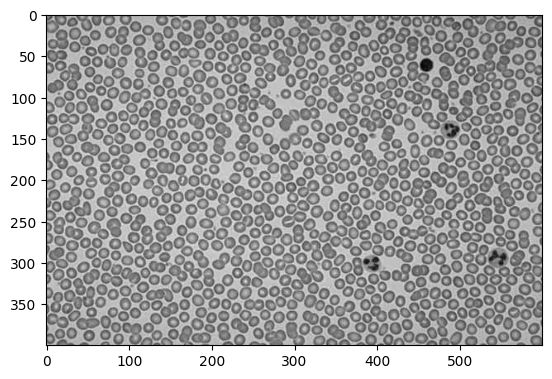

In [14]:
img = cv2.imread("../Imagenes_cursado/sangre.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.show()

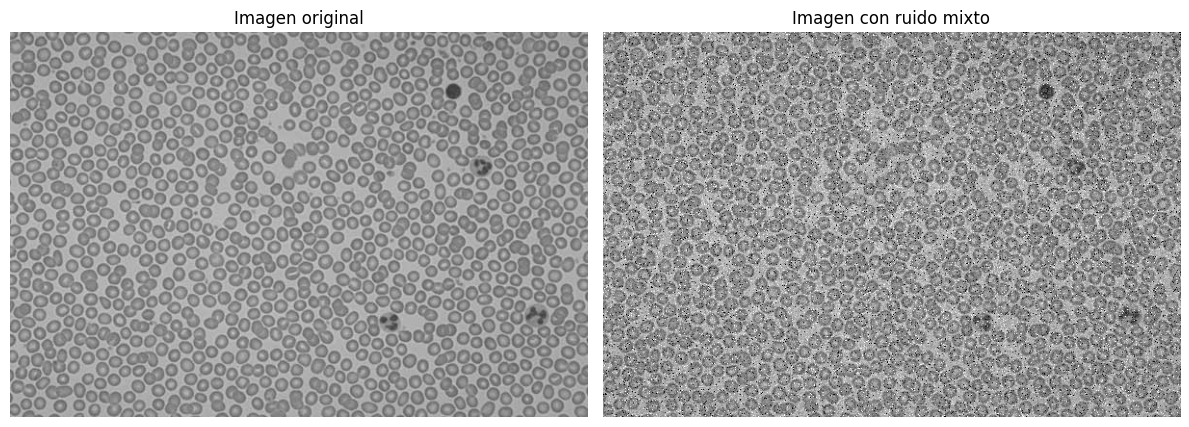

In [15]:
img_ruido = ruido_gaussiano(
    img,
    sigma=20
)

img_ruido = ruido_sal_pimienta(
    img_ruido.astype(np.uint8),
    prob=0.05
)


fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(img,cmap='gray',vmin=0,vmax=255)

ax[0].set_title("Imagen original")
ax[0].axis('off')

ax[1].imshow(img_ruido,cmap='gray',vmin=0,vmax=255)

ax[1].set_title("Imagen con ruido mixto")
ax[1].axis('off')

plt.tight_layout()
plt.show()

nos metemos a limpiar!

C:\Users\MATEOCRACK\AppData\Local\Temp\ipykernel_4480\4141561394.py:30: RuntimeWarning: divide by zero encountered in power
  num = np.sum(ventana**(Q+1))
C:\Users\MATEOCRACK\AppData\Local\Temp\ipykernel_4480\4141561394.py:31: RuntimeWarning: divide by zero encountered in power
  deno = np.sum(ventana**Q) + 1e-8
C:\Users\MATEOCRACK\AppData\Local\Temp\ipykernel_4480\4141561394.py:33: RuntimeWarning: invalid value encountered in scalar divide
  salida[i,j]= num/deno
C:\Users\MATEOCRACK\AppData\Local\Temp\ipykernel_4480\4141561394.py:35: RuntimeWarning: invalid value encountered in cast
  return np.clip(salida, 0, 255).astype(np.uint8)


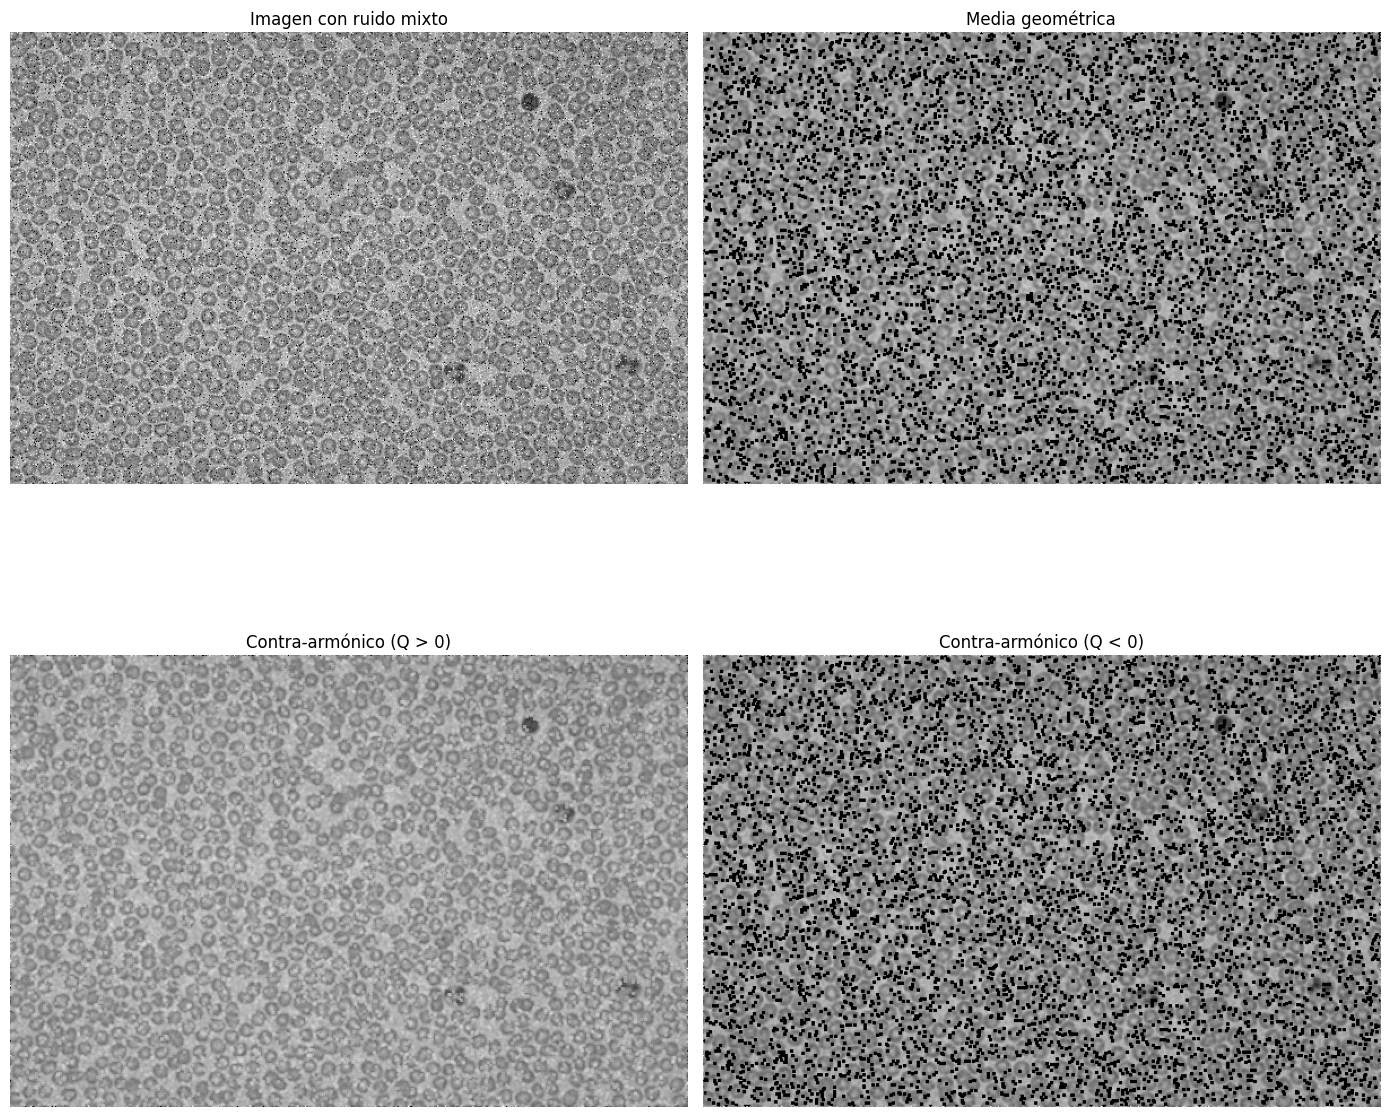

In [16]:
# Media geométrica
img_geo = filtro_media_geometrica(img_ruido,ksize=3)

img_contra_pimienta = filtro_contramedia_armonica(img_ruido,ksize=3,Q=1.5)
img_contra_sal = filtro_contramedia_armonica(img_ruido,ksize=3,Q=-1.5)

fig, ax = plt.subplots(2, 2, figsize=(14,14))


ax[0,0].imshow(img_ruido,cmap='gray',vmin=0,vmax=255)
ax[0,0].set_title("Imagen con ruido mixto")
ax[0,0].axis('off')


ax[0,1].imshow(img_geo,cmap='gray',vmin=0,vmax=255)
ax[0,1].set_title("Media geométrica")
ax[0,1].axis('off')

ax[1,0].imshow(img_contra_pimienta,cmap='gray',vmin=0,vmax=255)
ax[1,0].set_title("Contra-armónico (Q > 0)")
ax[1,0].axis('off')

ax[1,1].imshow(img_contra_sal,cmap='gray',vmin=0,vmax=255)
ax[1,1].set_title("Contra-armónico (Q < 0)")
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

DESASTROSOS. Hay que solucionar errores numericos en el contraarmonico.
- COmo era de esperar el geometrico es malo para ruido pimienta.
- El contraarmonico Q<0 elimino sal
- El contraarmonico Q>0 anduvo bastante bien

## COmparacion matematica

In [17]:
def ECM(img1, img2):

    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    return np.mean((img1 - img2)**2)

In [18]:
ecm_ruido = ECM(img, img_ruido) #imagen original

ecm_geo = ECM(img, img_geo)
ecm_contra_pimienta = ECM(img,img_contra_pimienta)
ecm_contra_sal = ECM(img,img_contra_sal)


print("=========== ECM ===========\n")
print(f"Imagen degradada: {ecm_ruido:.2f}")
print(f"Media geométrica: {ecm_geo:.2f}")
print(f"Contra-armónico Q>0: "
      f"{ecm_contra_pimienta:.2f}")
print(f"Contra-armónico Q<0: "
      f"{ecm_contra_sal:.2f}")


=========== ECM ===========

Imagen degradada: 1234.37
Media geométrica: 4640.72
Contra-armónico Q>0: 385.11
Contra-armónico Q<0: 4673.11


Como era de esperar, el mas cercano fue el contraarmonico Q>0

## Sobre la contraarmonica
Vamos a jugar un poco con la contraarmonica

In [ ]:
from ipywidgets import interact, FloatSlider

img = cv2.imread(
    "../Imagenes_cursado/sangre.jpg",
    cv2.IMREAD_GRAYSCALE
)

img_sal = ruido_sal(img, prob=0.05)
img_pimienta = ruido_pimienta(img, prob=0.05)



@interact(
    Q=FloatSlider(value=1.5,min=-5,max=5,step=0.1,description='Q')
)

def actualizar(Q):
    filtrada_sal = filtro_contramedia_armonica(img_sal,ksize=3,Q=Q)

    filtrada_pimienta = filtro_contramedia_armonica(img_pimienta,ksize=3,Q=Q)


    fig, ax = plt.subplots(2,2,figsize=(8,8))

    ax[0,0].imshow(img_sal,cmap='gray',vmin=0,vmax=255)
    ax[0,0].set_title("Ruido sal")
    ax[0,0].axis('off')

    ax[0,1].imshow(filtrada_sal,cmap='gray',vmin=0,vmax=255)
    ax[0,1].set_title(f"Filtrado sal (Q={Q:.1f})")
    ax[0,1].axis('off')

    ax[1,0].imshow(img_pimienta,cmap='gray',vmin=0,vmax=255)
    ax[1,0].set_title("Ruido pimienta")
    ax[1,0].axis('off')

    ax[1,1].imshow(filtrada_pimienta,cmap='gray',vmin=0,vmax=255)
    ax[1,1].set_title(f"Filtrado pimienta (Q={Q:.1f})")
    ax[1,1].axis('off')

    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=1.5, description='Q', max=5.0, min=-5.0), Output()), _dom_classes=('wi…

Q>0 me limpia la pimienta y me aclara la imagen (esto ultimo lo suponia nomas). Lo mismo opcurre con q negativo, oscurece la imagen.

# Ejercicio 3


In [20]:
def filtro_mediana(imagen, ksize=3):
    img = imagen.astype(np.float32)
    salida = img.copy()
    r = ksize // 2

    for i in range(r, img.shape[0]-r):
        for j in range(r, img.shape[1]-r):
            ventana = img[
                i-r:i+r+1,
                j-r:j+r+1
            ]
            salida[i,j] = np.median(ventana)
    return np.clip(salida, 0, 255).astype(np.uint8)

def filtro_punto_medio(imagen, ksize=3):

    img = imagen.astype(np.float32)
    salida = img.copy()
    r = ksize // 2
    for i in range(r, img.shape[0]-r):
        for j in range(r, img.shape[1]-r):
            ventana = img[
                i-r:i+r+1,
                j-r:j+r+1
            ]
            minimo = np.min(ventana)
            maximo = np.max(ventana)
            salida[i,j] = (minimo + maximo) / 2

    return np.clip(salida, 0, 255).astype(np.uint8)


def filtro_alpha_trimmed(imagen,ksize=3,d=2):

    img = imagen.astype(np.float32)
    salida = img.copy()
    r = ksize // 2

    for i in range(r, img.shape[0]-r):
        for j in range(r, img.shape[1]-r):
            ventana = img[
                i-r:i+r+1,
                j-r:j+r+1
            ]
            valores = np.sort(ventana.flatten())
            recortados = valores[d//2 : len(valores)-d//2]

            salida[i,j] = np.mean(recortados) #hacemos la media excluyendo los d

    return np.clip(salida, 0, 255).astype(np.uint8)

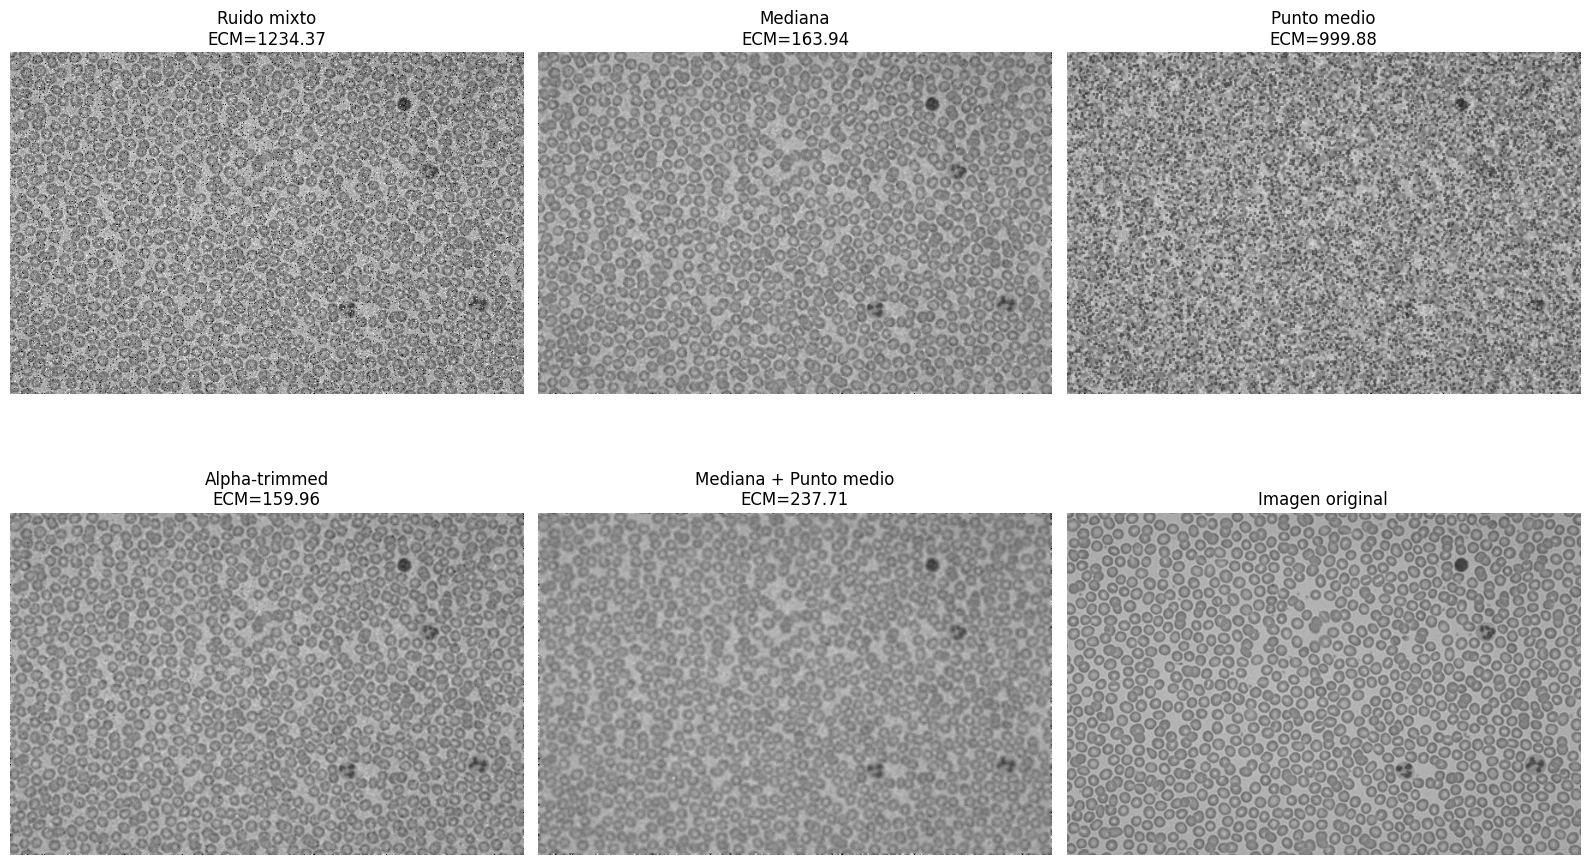

=========== ECM ===========

Imagen degradada: 1234.37
Filtro mediana: 163.94
Filtro punto medio: 999.88
Filtro alpha-trimmed: 159.96
Mediana + punto medio: 237.71


In [21]:

img_mediana = filtro_mediana(img_ruido,ksize=3)
img_punto_medio = filtro_punto_medio(img_ruido,ksize=3)
img_alpha = filtro_alpha_trimmed(img_ruido,ksize=3,d=2)

img_mediana_pmedio = filtro_punto_medio(img_mediana,ksize=3)



ecm_ruido = ECM(img, img_ruido)
ecm_mediana = ECM(img, img_mediana)
ecm_pmedio = ECM(img, img_punto_medio)
ecm_alpha = ECM(img, img_alpha)
ecm_mediana_pmedio = ECM(img,img_mediana_pmedio
)


fig, ax = plt.subplots(2, 3, figsize=(16,10))

ax[0,0].imshow(img_ruido,cmap='gray',vmin=0,vmax=255)
ax[0,0].set_title(f"Ruido mixto\nECM={ecm_ruido:.2f}")
ax[0,0].axis('off')

ax[0,1].imshow(img_mediana,cmap='gray',vmin=0,vmax=255)
ax[0,1].set_title(f"Mediana\nECM={ecm_mediana:.2f}")
ax[0,1].axis('off')


ax[0,2].imshow(img_punto_medio,cmap='gray',vmin=0,vmax=255)
ax[0,2].set_title(f"Punto medio\nECM={ecm_pmedio:.2f}")
ax[0,2].axis('off')

ax[1,0].imshow(img_alpha,cmap='gray',vmin=0,vmax=255)
ax[1,0].set_title(f"Alpha-trimmed\nECM={ecm_alpha:.2f}")
ax[1,0].axis('off')


ax[1,1].imshow(img_mediana_pmedio,cmap='gray',vmin=0,vmax=255)
ax[1,1].set_title(f"Mediana + Punto medio\nECM={ecm_mediana_pmedio:.2f}")
ax[1,1].axis('off')

ax[1,2].imshow(img,cmap='gray',vmin=0,vmax=255)
ax[1,2].set_title("Imagen original")
ax[1,2].axis('off')

plt.tight_layout()
plt.show()


print("=========== ECM ===========\n")
print(f"Imagen degradada: {ecm_ruido:.2f}")
print(f"Filtro mediana: {ecm_mediana:.2f}")
print(f"Filtro punto medio: {ecm_pmedio:.2f}")
print(f"Filtro alpha-trimmed: {ecm_alpha:.2f}")
print(f"Mediana + punto medio: "  f"{ecm_mediana_pmedio:.2f}")

EL alpha trimmed y mediana andan bien. Esto se debe ya que evitan a los extremos (potenciales salpimienta). En general lucen bastante mejores que los filtros de promedio. EL de mediana perdio como mas calidad que el alpha trimed

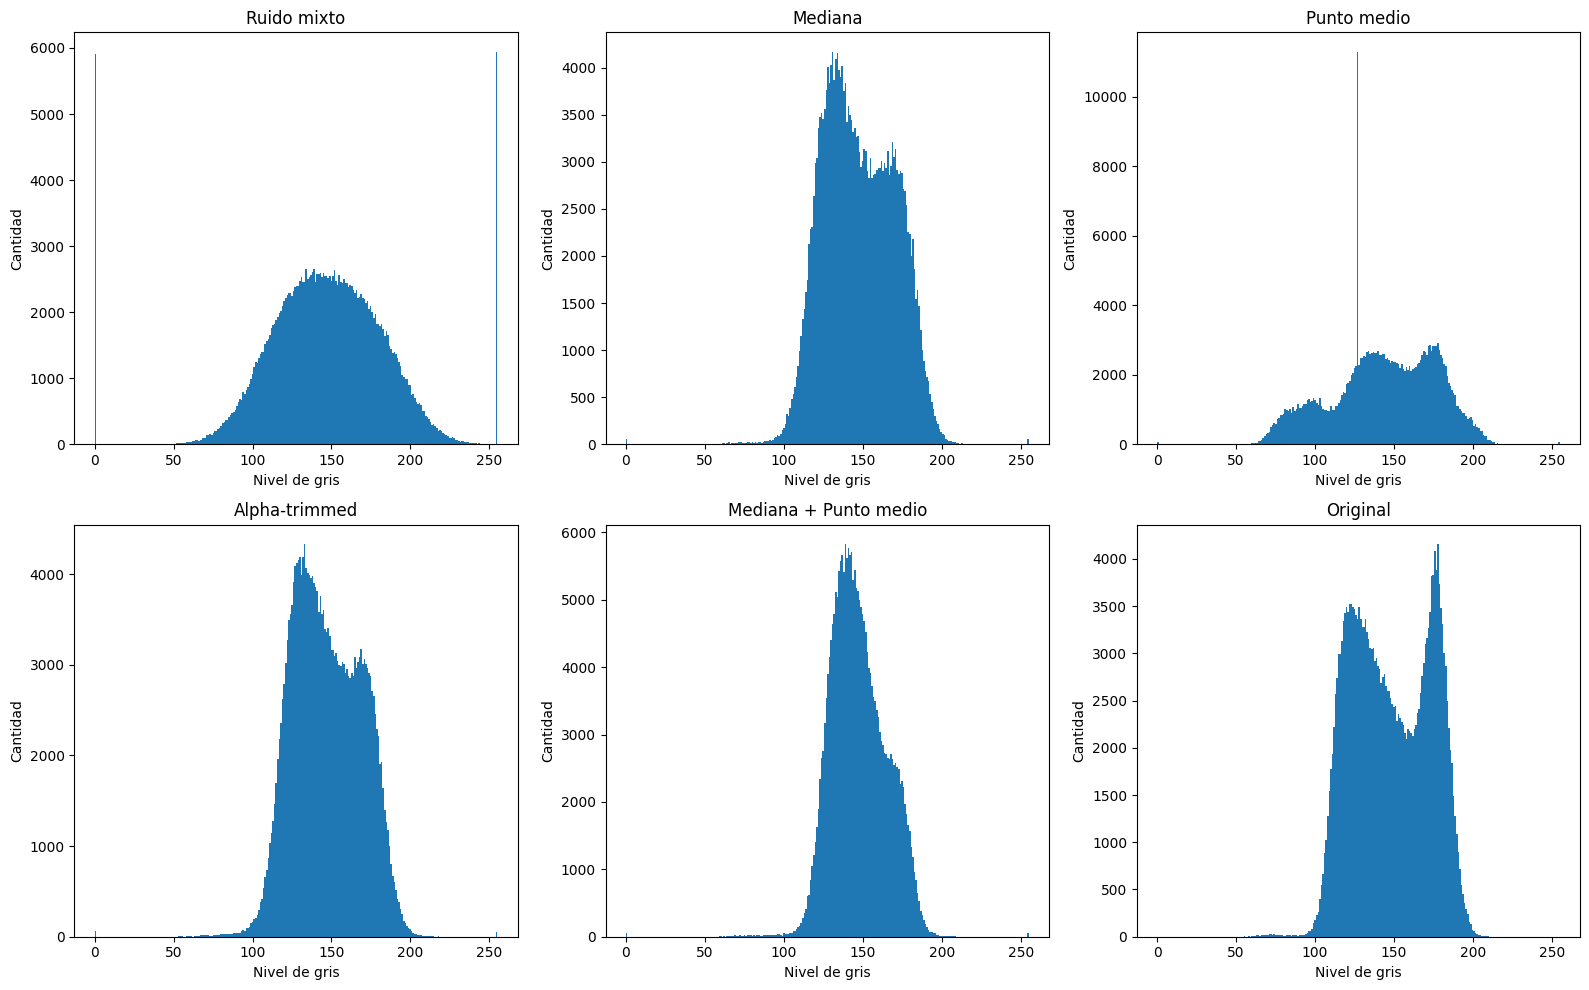

In [23]:

imagenes = [("Ruido mixto", img_ruido),("Mediana", img_mediana),("Punto medio", img_punto_medio),("Alpha-trimmed", img_alpha),("Mediana + Punto medio", img_mediana_pmedio),("Original", img)]

fig, ax = plt.subplots(2, 3, figsize=(16,10))
ax = ax.ravel()
for i, (titulo, imagen) in enumerate(imagenes):
    ax[i].hist(imagen.ravel(),bins=256,range=(0,255))
    ax[i].set_title(titulo)
    ax[i].set_xlabel("Nivel de gris")
    ax[i].set_ylabel("Cantidad")

plt.tight_layout()

plt.show()

Los que mejores andan se aproximan bastante a la distribucion original de los grises.